<a href="https://colab.research.google.com/github/sreevarshini22/genre-classification/blob/main/genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Shape: (54214, 4)

First 3 rows:
   ID                             Title     Genre  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   

                                                Plot  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  

Genre Distribution:
Genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history         

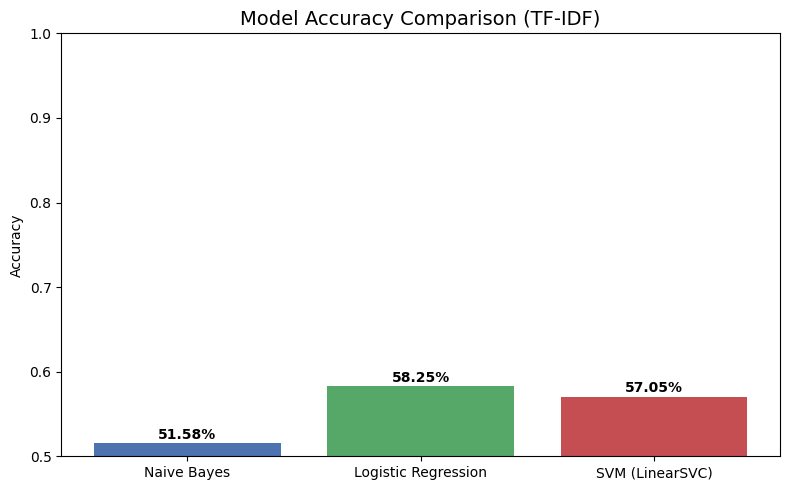

Chart saved as accuracy_comparison.png

Best Model: Logistic Regression


In [2]:
#imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
#Load Dataset
df = pd.read_csv('train_data.txt', sep=' ::: ', engine='python',header=None, names=['ID', 'Title', 'Genre', 'Plot'])
print("Dataset Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nGenre Distribution:")
print(df['Genre'].value_counts())
#Data Cleaning
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)              # remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens  # lemmatize
              if w not in stop_words and len(w) > 2]   # remove stopwords
    return ' '.join(tokens)
print("\nCleaning text...")
df['Cleaned_Plot'] = df['Plot'].apply(clean_text)
print("Done!")
#Encoded Labels
le = LabelEncoder()
df['Genre_Encoded'] = le.fit_transform(df['Genre'])
print(f"\nNumber of unique genres: {len(le.classes_)}")
print("Genres:", list(le.classes_))
#Train and Test Split
X = df['Cleaned_Plot']
y = df['Genre_Encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")
#Feature Extraction
print("\nBuilding TF-IDF features...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
#Training models
models = {
    "Naive Bayes":        MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (LinearSVC)":    LinearSVC(max_iter=1000, random_state=42)
}

results = {}

print("\n" + "="*55)
print("         MODEL COMPARISON (TF-IDF Features)")
print("="*55)
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"\n-- {name} --")
    print(f"   Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                zero_division=0))
#plot accuracy comparison
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison (TF-IDF)', fontsize=14)
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()
print("Chart saved as accuracy_comparison.png")
#confusion matrix
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_preds      = results[best_model_name]['predictions']
print(f"\nBest Model: {best_model_name}")
# Only plot if genres are manageable
if len(le.classes_) <= 20:
    cm = confusion_matrix(y_test, best_preds)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("Confusion matrix saved as confusion_matrix.png")

#PREDICT ON NEW PLOT
def predict_genre(plot_text, model, vectorizer, label_encoder):
    cleaned  = clean_text(plot_text)
    features = vectorizer.transform([cleaned])
    encoded  = model.predict(features)[0]
    genre    = label_encoder.inverse_transform([encoded])[0]
    return genre

